# Example 3 — Trident rates at all DarkNews experiments

`neptune` reads target nuclei, POT exposures and flux files straight from `DarkNews.detector.Detector`. This notebook walks through every experiment registered in DarkNews and computes the SM coherent + diffractive trident rate for the canonical dimuon channel
$$
\nu_\mu + N \to \nu_\mu + \mu^- + \mu^+ + N\,.
$$

Same rate convention as DarkNews:

$$
N_\text{events}\;=\;\text{POT} \times \sum_{\text{targets}} N_\text{nuclei}^{(t)} \,\int \mathrm{d}E_\nu\;\Phi(E_\nu)\,\sigma(E_\nu)\,,
$$

where $\sigma(E_\nu) = \sigma_\text{coh}^{(t)}(E_\nu) + Z^{(t)}\,\sigma_\text{diff}^{(t)}(E_\nu)$ is the per-nucleus total. The diffractive piece uses the proton dipole form factor and is multiplied by $Z$ (number of protons); the sub-dominant neutron magnetic contribution is neglected. The coherent/diffractive boundary uses the C++ default $Q_\text{max}^\text{coh} = \Lambda_{\rm QCD} / A^{1/3}$.

In [1]:
%load_ext autoreload
%autoreload 2

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import neptune as nep
from DarkNews.detector import Detector

warnings.filterwarnings('ignore')   # silence vegas/scipy info noise
print('neptune', nep.__version__)

neptune 0.1.0


## 1) DarkNews experiment registry

All keys come straight from `DarkNews.detector.Detector.KEYWORDS`. We drop the `*_dirt` and `*_tpc` variants here because they share a flux with their parent geometry — feel free to add them back.

In [2]:
all_keys = list(Detector.KEYWORDS)
experiments = [k for k in all_keys if not (k.endswith('_dirt') or k.endswith('_dirt_cone') or k == 'microboone_tpc')]
print(f'{len(experiments)} experiments selected:')
for k in experiments:
    print('  ', k)

15 experiments selected:
   dune_nd_fhc
   dune_nd_rhc
   sbnd
   microboone
   minerva_le_fhc
   minerva_me_fhc
   minerva_me_rhc
   miniboone_fhc
   icarus
   miniboone_rhc
   minos_le_fhc
   nd280_fhc
   nova_le_fhc
   fasernu
   nutev_fhc


## 2) Helper: trident rate for one experiment, one channel

For each `(nu_flavor, l1, l2)` channel we build a `TridentSMModel` and run a flux-folded Vegas integration once per nuclear target in the detector. The rates are summed over targets and over $\nu / \bar\nu$ projectiles of the chosen flavor. We use modest Vegas settings (`nitn=4`, `neval=4000`) to keep the whole survey under a few minutes; bump them up for production-quality numbers.

In [3]:
from DarkNews import pdg as dn_pdg
PDG = {
    'e':   (dn_pdg.nue,   dn_pdg.nuebar),
    'mu':  (dn_pdg.numu,  dn_pdg.numubar),
    'tau': (dn_pdg.nutau, dn_pdg.nutaubar),
}

def trident_rate(experiment, nu_flavor='mu', l1_flavor='mu', l2_flavor='mu',
                 include_nubar=True, nitn=4, neval=4_000):
    """
    Returns a dict with the trident yield for a single DarkNews experiment.
    Sums coherent + diffractive on every nuclear target in the detector,
    and over both nu and nubar projectiles when include_nubar=True.
    """
    det = Detector(experiment)
    Emin, Emax = float(det.ERANGE[0]), float(det.ERANGE[1])
    proj_nu, proj_nubar = PDG[nu_flavor]
    projectiles = [(proj_nu, False)] + ([(proj_nubar, True)] if include_nubar else [])

    rows = []
    for proj, is_nubar in projectiles:
        flux = det.neutrino_flux(proj)
        # Most flux files are zero outside the projected band — skip if integral is tiny
        Egrid = np.linspace(Emin, Emax, 200)
        if np.trapezoid(flux(Egrid), Egrid) <= 0:
            continue
        model = nep.TridentSMModel(
            nu_flavor=nu_flavor, l1_flavor=l1_flavor, l2_flavor=l2_flavor,
            is_nubar=is_nubar,
        )
        for tgt in det.NUCLEAR_TARGETS:
            Z, A = int(tgt.Z), int(tgt.A)
            n_nuclei = float(det.NUMBER_OF_TARGETS[tgt.name])
            proc = nep.TridentProcess(
                model, Z=Z, A=A,
                Enu=None, Emin=Emin, Emax=Emax, flux=flux,
                nitn=nitn, neval=neval,
            )
            res = proc.sigma_total(nitn=nitn, neval=neval)
            coh, coh_e = res['coherent']             # cm^2 * (flux units) per nucleus
            dif, dif_e = res['diffractive']           # per proton
            sigma_phi, sigma_phi_err = res['total_per_nucleus']
            N = float(det.POTS) * n_nuclei * sigma_phi
            N_err = float(det.POTS) * n_nuclei * sigma_phi_err
            rows.append(dict(
                experiment=experiment, projectile=('nu' if not is_nubar else 'nubar'),
                target=tgt.name, Z=Z, A=A, n_nuclei=n_nuclei, POTs=float(det.POTS),
                Emin=Emin, Emax=Emax,
                sigma_phi_coh=coh, sigma_phi_dif=dif * Z, sigma_phi_tot=sigma_phi,
                N_coh=float(det.POTS) * n_nuclei * coh,
                N_dif=float(det.POTS) * n_nuclei * Z * dif,
                N=N, N_err=N_err,
            ))
    return rows

## 3) Loop over all experiments

This takes a few minutes on a laptop; reduce `nitn`/`neval` (or comment out experiments) for a quick pass.

In [4]:
all_rows = []
t0 = time.time()
for exp in experiments:
    try:
        t1 = time.time()
        rows = trident_rate(exp, nu_flavor='mu', l1_flavor='mu', l2_flavor='mu')
        all_rows.extend(rows)
        n_events = sum(r['N'] for r in rows)
        print(f'  {exp:25s}  ->  {n_events:.3e} dimuon trident events  ({time.time()-t1:.1f}s)')
    except Exception as err:
        print(f'  {exp:25s}  -> SKIPPED ({type(err).__name__}: {err})')
print(f'total wall time: {time.time()-t0:.1f}s')

df = pd.DataFrame(all_rows)
df.head()

  dune_nd_fhc                ->  3.971e+02 dimuon trident events  (0.3s)


  dune_nd_rhc                ->  3.497e+02 dimuon trident events  (0.3s)


  sbnd                       ->  4.872e-01 dimuon trident events  (0.3s)


  microboone                 ->  2.803e-02 dimuon trident events  (0.3s)


  minerva_le_fhc             ->  1.264e+00 dimuon trident events  (0.6s)


...

  nd280_fhc                  ->  4.738e-01 dimuon trident events  (1.7s)


  nova_le_fhc                ->  1.313e+01 dimuon trident events  (1.4s)


  fasernu                    ->  1.375e+01 dimuon trident events  (0.3s)


  nutev_fhc                  ->  1.249e+02 dimuon trident events  (0.6s)
total wall time: 8.7s


,experiment,projectile,target,Z,A,n_nuclei,POTs,Emin,Emax,sigma_phi_coh,sigma_phi_dif,sigma_phi_tot,N_coh,N_dif,N,N_err
0,dune_nd_fhc,nu,Ar40,18,40,4.521973e+29,1.000000e+22,0.05,40.0,5.100395e-50,2.143557e-50,7.243952e-50,230.638460,96.931058,327.569519,1.970021
1,dune_nd_fhc,nubar,Ar40,18,40,4.521973e+29,1.000000e+22,0.05,40.0,1.105169e-50,4.326248e-51,1.537794e-50,49.975457,19.563174,69.538631,0.400428
2,dune_nd_rhc,nu,Ar40,18,40,4.521973e+29,1.000000e+22,0.05,40.0,2.182466e-50,7.774381e-51,2.959904e-50,98.690496,35.155539,133.846035,0.592626
3,dune_nd_rhc,nubar,Ar40,18,40,4.521973e+29,1.000000e+22,0.05,40.0,3.152984e-50,1.621387e-50,4.774372e-50,142.577085,73.318696,215.895781,1.860143
4,sbnd,nu,Ar40,18,40,1.688203e+30,1.560000e+21,0.05,3.0,8.815938e-53,9.047728e-53,1.786367e-52,0.232176,0.238281,0.470457,0.002771


## 4) Per-experiment summary table

We collapse over targets and over ν/ν̄ projectiles to get a single number per experiment, plus the breakdown into coherent / diffractive.

In [5]:
summary = df.groupby('experiment', sort=False).agg(
    N_total=('N',     'sum'),
    N_coh  =('N_coh', 'sum'),
    N_dif  =('N_dif', 'sum'),
    POTs   =('POTs',  'first'),
    targets=('target', lambda s: '+'.join(sorted(set(s)))),
).reset_index()
summary['frac_coh'] = summary['N_coh'] / summary['N_total']
summary = summary.sort_values('N_total', ascending=False).reset_index(drop=True)

fmt = summary.style.format({
    'N_total': '{:.3e}', 'N_coh': '{:.3e}', 'N_dif': '{:.3e}',
    'POTs': '{:.2e}', 'frac_coh': '{:.2f}',
})
fmt

,experiment,N_total,N_coh,N_dif,POTs,targets,frac_coh
0,dune_nd_fhc,3.971e+02,2.806e+02,1.165e+02,1.00e+22,Ar40,0.71
1,dune_nd_rhc,3.497e+02,2.413e+02,1.085e+02,1.00e+22,Ar40,0.69
2,nutev_fhc,1.249e+02,1.025e+02,2.239e+01,5.00e+18,C12+Fe56,0.82
3,minerva_me_fhc,1.600e+01,9.443e+00,6.554e+00,1.16e+21,C12+H1,0.59
4,minerva_me_rhc,1.598e+01,9.457e+00,6.521e+00,1.16e+21,C12+H1,0.59
5,fasernu,1.375e+01,1.251e+01,1.232e+00,1.00e+00,W184,0.91
6,nova_le_fhc,1.313e+01,7.772e+00,5.356e+00,1.36e+21,C12+Cl35+H1+O16+Ti48,0.59
7,minos_le_fhc,6.044e+00,4.346e+00,1.698e+00,2.80e+20,C12+Fe56,0.72
8,minerva_le_fhc,1.264e+00,7.423e-01,5.215e-01,3.43e+20,C12+H1,0.59
9,sbnd,4.872e-01,2.400e-01,2.472e-01,1.56e+21,Ar40,0.49


## 5) Bar chart — events per experiment, coherent vs diffractive

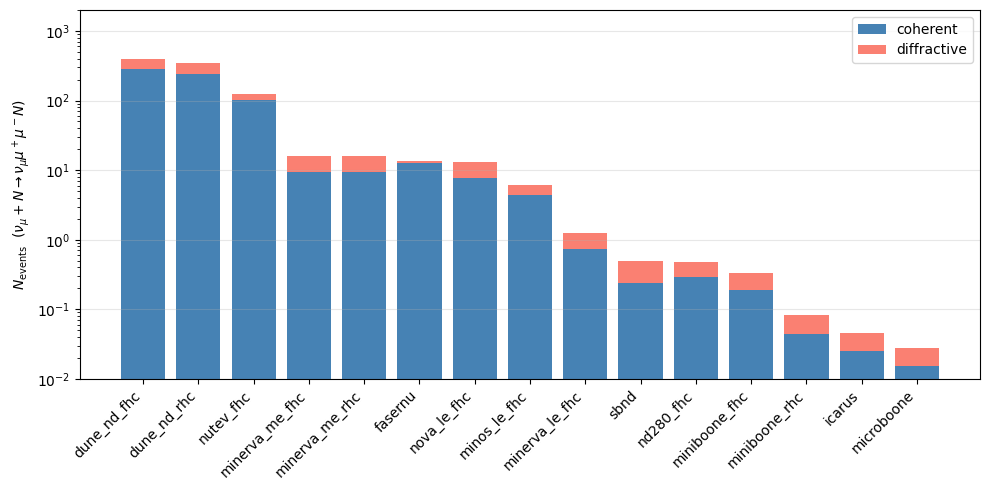

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary))
ax.bar(x, summary['N_coh'], label='coherent',  color='steelblue')
ax.bar(x, summary['N_dif'], bottom=summary['N_coh'], label='diffractive', color='salmon')
ax.set_yscale('log')
ax.set_ylim(1e-2, 2e3)
ax.set_xticks(x)
ax.set_xticklabels(summary['experiment'], rotation=45, ha='right')
ax.set_ylabel(r'$N_\mathrm{events}$  ($\nu_\mu + N \to \nu_\mu \mu^+ \mu^- N$)')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()

## 6) Spotlight: DUNE FHC — per-target and per-projectile breakdown

The full row-level DataFrame `df` lets you slice by target nucleus or projectile. For DUNE FHC the only target is Ar-40, but for multi-target detectors (NOvA, MINERvA, ND280, …) you can see the per-nucleus contributions.

In [7]:
for exp in ['dune_nd_fhc', 'minerva_me_fhc', 'nova_le_fhc']:
    sel = df[df['experiment'] == exp]
    if sel.empty:
        continue
    print(f'\n=== {exp} ===')
    print(sel[['projectile', 'target', 'A', 'n_nuclei',
               'sigma_phi_coh', 'sigma_phi_dif', 'N_coh', 'N_dif', 'N']]
          .to_string(index=False, float_format=lambda x: f'{x:.3e}'))


=== dune_nd_fhc ===
projectile target  A  n_nuclei  sigma_phi_coh  sigma_phi_dif     N_coh     N_dif         N
        nu   Ar40 40 4.522e+29      5.100e-50      2.144e-50 2.306e+02 9.693e+01 3.276e+02
     nubar   Ar40 40 4.522e+29      1.105e-50      4.326e-51 4.998e+01 1.956e+01 6.954e+01

=== minerva_me_fhc ===
projectile target  A  n_nuclei  sigma_phi_coh  sigma_phi_dif     N_coh     N_dif         N
        nu    C12 12 2.625e+29      2.563e-50      1.541e-50 7.805e+00 4.691e+00 1.250e+01
        nu     H1  1 5.210e+29      1.965e-51      2.535e-51 1.187e+00 1.532e+00 2.720e+00
     nubar    C12 12 2.625e+29      1.298e-51      8.200e-52 3.950e-01 2.497e-01 6.447e-01
     nubar     H1  1 5.210e+29      9.315e-53      1.346e-52 5.630e-02 8.136e-02 1.377e-01

=== nova_le_fhc ===
projectile target  A  n_nuclei  sigma_phi_coh  sigma_phi_dif     N_coh     N_dif         N
        nu     H1  1 1.246e+31      4.786e-53      5.357e-53 8.111e-01 9.080e-01 1.719e+00
        nu    C12 12 6.4

## 7) Other lepton channels

Repeat the survey for $\nu_\mu \to \nu_\mu e^+ e^-$ (NC-only dielectron) and $\nu_e \to \nu_e e^+ e^-$ (CC + NC). The dimuon-vs-dielectron ratio at fixed $E_\nu$ flips around the muon-pair threshold, so this is a useful cross-check.

In [8]:
channels = [
    ('mu', 'mu', 'mu'),    # nu_mu -> nu_mu mu+ mu-
    ('mu', 'e',  'e'),     # nu_mu -> nu_mu e+ e-
    ('e',  'e',  'e'),     # nu_e  -> nu_e  e+ e-
]
ch_rows = []
for nu, l1, l2 in channels:
    for exp in ['dune_nd_fhc', 'sbnd', 'microboone', 'miniboone_fhc', 'minerva_me_fhc']:
        rows = trident_rate(exp, nu_flavor=nu, l1_flavor=l1, l2_flavor=l2,
                            nitn=3, neval=3_000)
        N = sum(r['N'] for r in rows)
        ch_rows.append(dict(experiment=exp,
                            channel=f'nu_{nu} -> {l1}-{l2}+',
                            N=N))
ch_df = pd.DataFrame(ch_rows).pivot(index='experiment', columns='channel', values='N')
ch_df.style.format('{:.3e}')

channel,nu_e -> e-e+,nu_mu -> e-e+,nu_mu -> mu-mu+
experiment,,,
dune_nd_fhc,2.335e+02,2.441e+03,3.990e+02
microboone,5.322e-02,1.692e+00,2.866e-02
minerva_me_fhc,2.101e+00,4.369e+01,1.577e+01
miniboone_fhc,2.625e-01,8.194e+00,3.297e-01
sbnd,1.572e+00,4.698e+01,4.846e-01


## 8) Notes

* Cross sections are SM only here (`TridentSMModel`). Swap in `TridentBSMModel` to fold in a $Z'$.
* The diffractive piece uses the per-nucleon dipole form factor times $A$. Pauli blocking is applied automatically.
* The flux integration window is taken from `Detector.ERANGE`; if your flux extends below the trident threshold the contribution is harmless (cross section vanishes).
* For higher precision bump `nitn` and `neval`. The numbers above will fluctuate at the 5–10% level run-to-run because of Vegas statistics.